In [1]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

import numpy as np
import json, os, math, glob
import importlib
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output, display

from alvra_tools.utils import *
from alvra_tools.channels import *
from alvra_tools.analysis_apo import *
from alvra_tools.alvra_widgets import Rebin_widget, RunSelectorUI, scan_runs
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

In [2]:
pgroup = 'p22591'
#runlist = np.arange(205, 224)
runlist = [56]

data, meta = merge_multiple_runs(pgroup, runlist)

Processing run 56


100%|██████████| 48/48 [02:18<00:00,  2.89s/it]


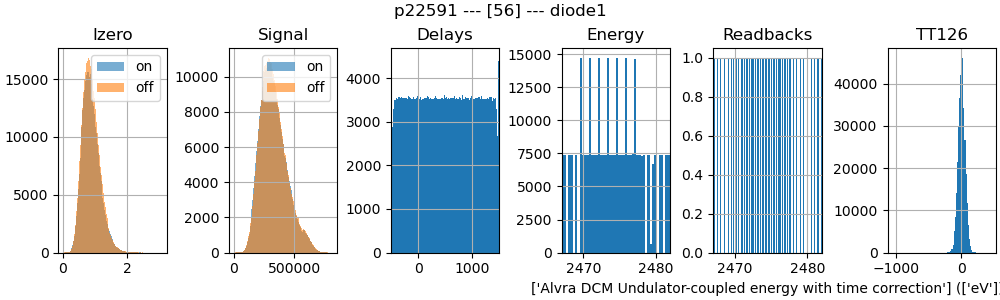

In [3]:
plot_merged_data(data, meta, Signal='diode1', Izero='Izero122', TT='126', withTT=False, bins=100, figsize=(10, 3))

In [14]:
7.594735 - 7.5016

0.09313500000000019

In [4]:
ui, out  = Rebin_widget(data=data)
ui

In [5]:
data_plot1 = out["signal1"]
#data_plot2 = out["signal2"]

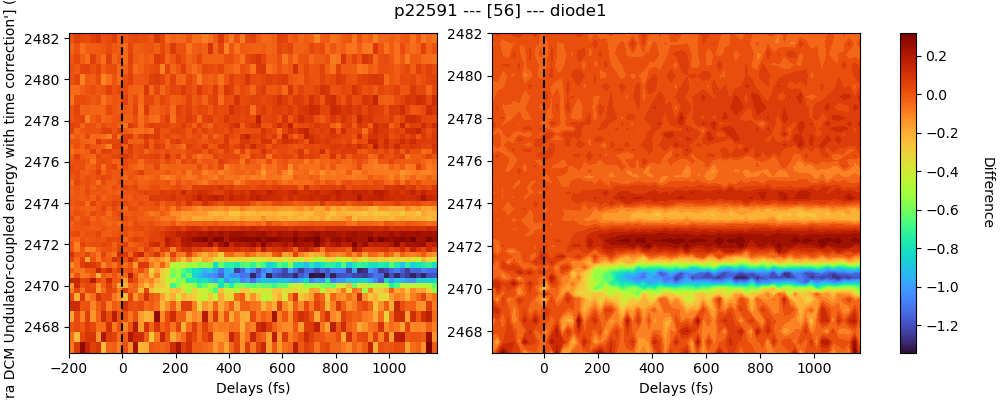

In [6]:
fig, axes = plotter.TwoD_scans(data_plot1, meta) #, vmin=-0.02, vmax=0.02)
#fig, axes = plotter.TwoD_scans(data_plot2, meta) #, vmin=0, vmax=20000)

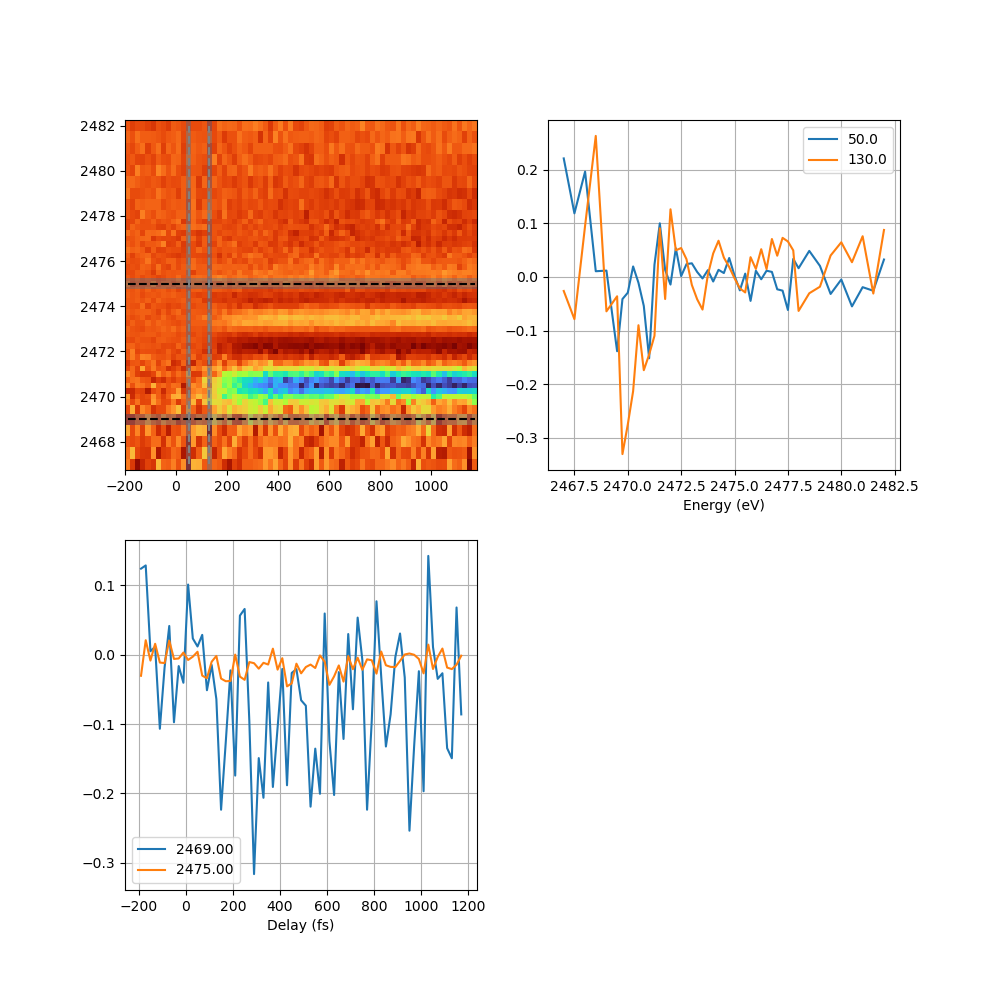

In [12]:
#energylist = [2470.0, 2471.7, 2472.5,  2475.5]
#delayslist = [0, 25, 50, 100, 200, 500, 800]
energylist = [2469, 2475]
delayslist = [50, 130]

fig, axes = plotter.TwoD_scans_lineouts(data_plot1, meta, energylist, delayslist, delay_int=20, energy_int = 0.5, figsize=(10,10))#, vmin=-0.02, vmax=0.02)

In [32]:
SaveDir = '/sf/alvra/data/{}/work/Reduced_data/'.format(pgroup)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2, plot_both=None)

Data saved in /sf/alvra/data/p22588/work/Reduced_data/_singlerun/run0117/


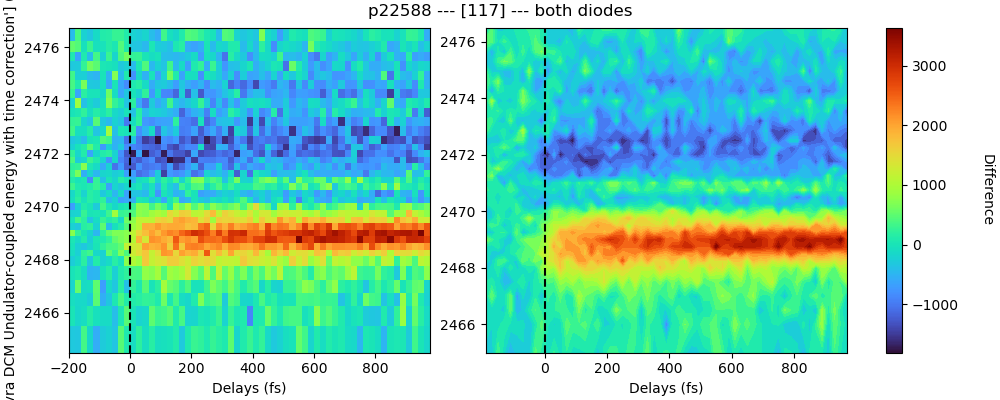

In [46]:
data_plot_both = average_two_diodes(data_plot1, data_plot2)
fig, axes = plotter.TwoD_scans(data_plot_both, meta)

In [93]:
pgroup = 'p22250'
which_plot = 'plot1' #both #plot1

LoadDir = '/sf/alvra/data/{}/work/Reduced_data/'.format(pgroup)
selector = RunSelectorUI(LoadDir)

Loaded __diode1__ from: /sf/alvra/data/p22250/work/Reduced_data/_multiruns/run0205_0206_0207_0208_0209_0210_0211_0212_0213_0214_0215_0216_0217_0218_0219_0220_0221_0222_0223/data.npz


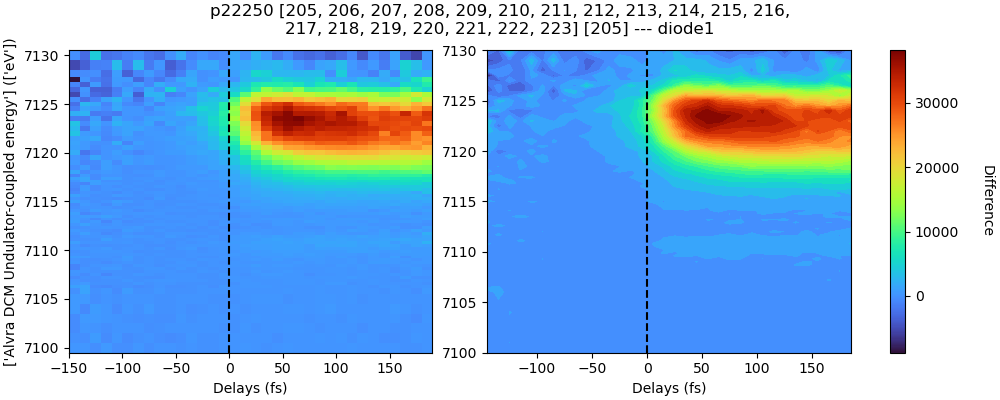

In [120]:
runlist2load = selector.runlist
dataLoaded, runnames, whichdiode = LoadDataAuto(LoadDir, runlist2load, which_plot=which_plot)
meta.update({'title': meta['title'].replace('---', str(runlist2load[0]))})
fig, axes = plotter.TwoD_scans(dataLoaded[0], meta) #, vmin=-0.02, vmax=0.02)

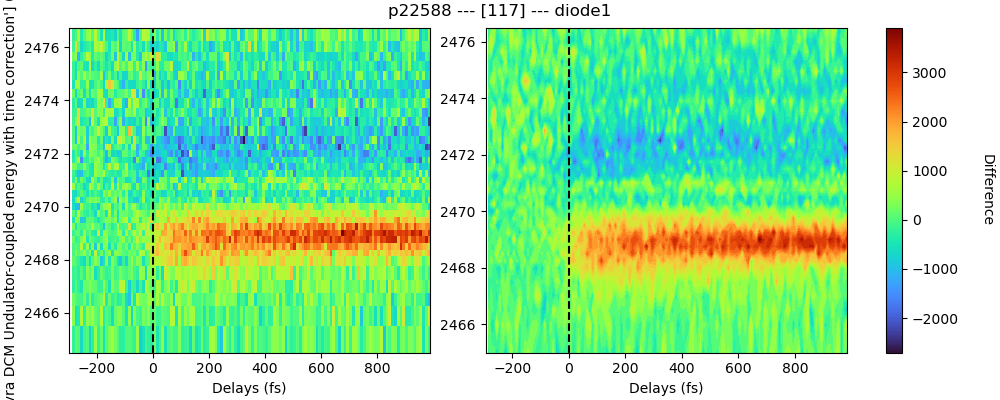

In [29]:
fig, axes = plotter.TwoD_scans(dataLoaded[0], meta) #, vmin=-0.02, vmax=0.02)